<a href="https://colab.research.google.com/github/tsnuhithreddy/loan-default-risk-analysis/blob/main/notebooks/Loan_default_risk_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Dataset
df = pd.read_csv("/content/credit_risk_dataset.csv")

# Dataset shape
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print()

# Data types
print(df.dtypes)
print()

# Preview
df.head()

Rows: 32581
Columns: 12

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object



,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [2]:
#Missing values
print("\n Missing values: \n")
missing=df.isnull().sum()
missing_percent=(missing/df.shape[0]*100).round(2)
print(missing_percent)

missing_data=pd.DataFrame({
    "Missing values":missing,
    "Missing %":missing_percent
})
missing_data=missing_data[missing_data["Missing values"]>0]
if missing_data.empty:
  print("No missing values")
else:
  print(missing_data)


 Missing values: 

person_age                    0.00
person_income                 0.00
person_home_ownership         0.00
person_emp_length             2.75
loan_intent                   0.00
loan_grade                    0.00
loan_amnt                     0.00
loan_int_rate                 9.56
loan_status                   0.00
loan_percent_income           0.00
cb_person_default_on_file     0.00
cb_person_cred_hist_length    0.00
dtype: float64
                   Missing values  Missing %
person_emp_length             895       2.75
loan_int_rate                3116       9.56


In [3]:
#Numerical data
duplicates=df.duplicated().sum()
print(f"Number of duplicates: {duplicates}")
print(df.describe().round(2))


Number of duplicates: 165
       person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
count    32581.00       32581.00           31686.00   32581.00       29465.00   
mean        27.73       66074.85               4.79    9589.37          11.01   
std          6.35       61983.12               4.14    6322.09           3.24   
min         20.00        4000.00               0.00     500.00           5.42   
25%         23.00       38500.00               2.00    5000.00           7.90   
50%         26.00       55000.00               4.00    8000.00          10.99   
75%         30.00       79200.00               7.00   12200.00          13.47   
max        144.00     6000000.00             123.00   35000.00          23.22   

       loan_status  loan_percent_income  cb_person_cred_hist_length  
count     32581.00             32581.00                    32581.00  
mean          0.22                 0.17                        5.80  
std           0.41                

In [4]:
#Categorical data
categories=["person_home_ownership","loan_intent","loan_grade","cb_person_default_on_file"]
for col in categories:
  print(df[col].value_counts())

person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


In [5]:
#Invalid records
invalid_employee=df[df['person_emp_length']>(df['person_age']-16)]
print(f"Number of invalid records: {len(invalid_employee)}")
print(invalid_employee[["person_age", "person_emp_length"]].head(10))

Number of invalid records: 740
     person_age  person_emp_length
0            22              123.0
9            21                6.0
18           23                8.0
65           22                7.0
68           24                9.0
72           21                6.0
125          23                8.0
141          26               11.0
171          21                6.0
210          21              123.0


In [6]:
#Data Cleaning

In [7]:
#remove duplicates
original_rows=len(df)
emp_nulls_before = df['person_emp_length'].isnull().sum()
print(f"emp_length nulls before duplicate removal: {emp_nulls_before}")
print()
df=df.drop_duplicates()
df=df.reset_index(drop=True)
emp_nulls_after = df['person_emp_length'].isnull().sum()
print(f"emp_length nulls after duplicate removal: {emp_nulls_after}")
print(f"nulls lost in duplicate removal: {emp_nulls_before - emp_nulls_after}")
print(f"duplicates removed: {original_rows - len(df)}")


emp_length nulls before duplicate removal: 895

emp_length nulls after duplicate removal: 887
nulls lost in duplicate removal: 8
duplicates removed: 165


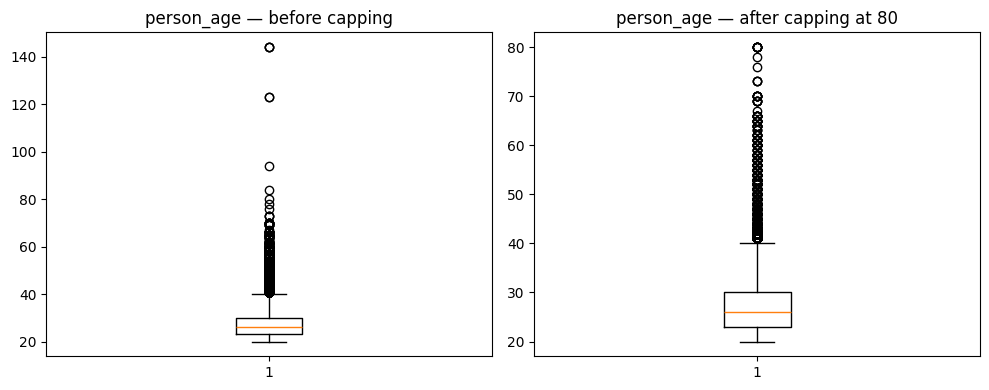

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(df['person_age'].dropna())
axes[0].set_title('person_age — before capping')
axes[1].boxplot(df['person_age'].clip(upper=80))
axes[1].set_title('person_age — after capping at 80')
plt.tight_layout()
plt.show()

In [9]:
#Fixing impossible age values
#Capping at 80 as reasonable maximum for a loan applicant
print(f"Ages above 80:{len(df[df['person_age']>80])}")
df['person_age']=df['person_age'].clip(upper=80)
print(f"Ages above 80:{len(df[df['person_age']>80])}")
assert df['person_age'].max() <= 80, "Age cap failed"

Ages above 80:7
Ages above 80:0


In [10]:
#Fixing impossible employment lengths
print(f"Impossible employment lengths: {len(df[df['person_emp_length']>df['person_age']-16])}")
max_possible_emp_length = df['person_age'] - 16
df['person_emp_length'] = np.minimum(df['person_emp_length'], max_possible_emp_length)

print(f"Impossible employment lengths after: {len(df[df['person_emp_length']>(df['person_age']-16)])}")
print(f"Maximum employment length after fix: {df['person_emp_length'].max()}")
valid = df['person_emp_length'].notnull()
assert (df.loc[valid, 'person_emp_length'] <= df.loc[valid, 'person_age'] - 16).all(), "Employment length cap failed"

Impossible employment lengths: 737
Impossible employment lengths after: 0
Maximum employment length after fix: 41.0


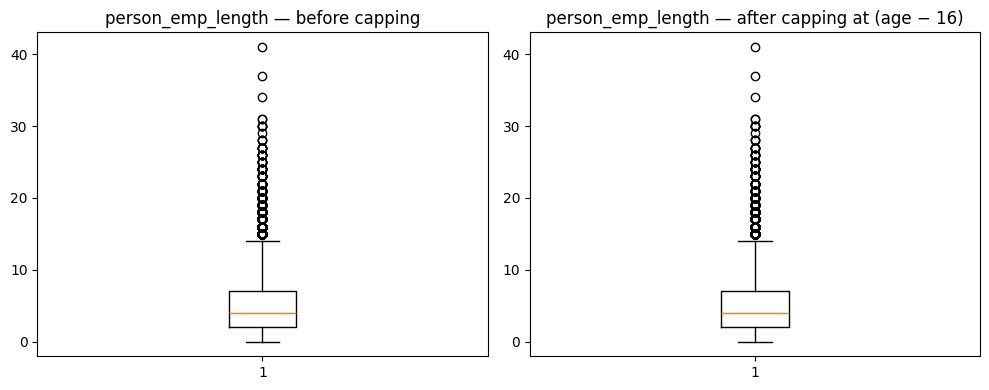

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(df['person_emp_length'].dropna())
axes[0].set_title('person_emp_length — before capping')
axes[1].boxplot(np.minimum(df['person_emp_length'], df['person_age'] - 16).dropna())
axes[1].set_title('person_emp_length — after capping at (age − 16)')
plt.tight_layout()
plt.show()

In [12]:
#Handling Employement Null values
df['is_unemployed']=df['person_emp_length'].isnull().astype(int)
df['person_emp_length']=df['person_emp_length'].fillna(0)
print(f"Number of null values in employement length: {df['person_emp_length'].isnull().sum()}")
print(f"Unemployed borrowers flagged as 1: {df['is_unemployed'].sum()}")
assert df['person_emp_length'].isnull().sum() == 0, "Unfilled emp_length nulls remain"

Number of null values in employement length: 0
Unemployed borrowers flagged as 1: 887


In [13]:
#Handling Interest Rate nulls
print(f"Missing interet rate values: {df['loan_int_rate'].isnull().sum()}")
df['loan_int_rate']=df.groupby('loan_grade')['loan_int_rate'].transform(lambda x:x.fillna(x.median()))
print(f"Missing interet rate values after: {df['loan_int_rate'].isnull().sum()}")
print("\n Median interest rate by grade:")
print(df.groupby('loan_grade')['loan_int_rate'].median().round(2))
assert df['loan_int_rate'].isnull().sum() == 0, "Unfilled interest rate nulls remain"


Missing interet rate values: 3095
Missing interet rate values after: 0

 Median interest rate by grade:
loan_grade
A     7.49
B    10.99
C    13.48
D    15.31
E    16.82
F    18.54
G    20.16
Name: loan_int_rate, dtype: float64


In [14]:
Q1=df['person_income'].quantile(0.25)
Q3=df['person_income'].quantile(0.75)
IQR=Q3-Q1
upper_bound=Q3+1.5*IQR
income_before_capping = df['person_income'].copy()   # snapshot for the before/after plot
print(f"Income above fence:${upper_bound}")
print(f"Number of outliers:{len(df[df['person_income']>upper_bound])}")
df['person_income']=df['person_income'].clip(upper=upper_bound)

Income above fence:$140232.0
Number of outliers:1478


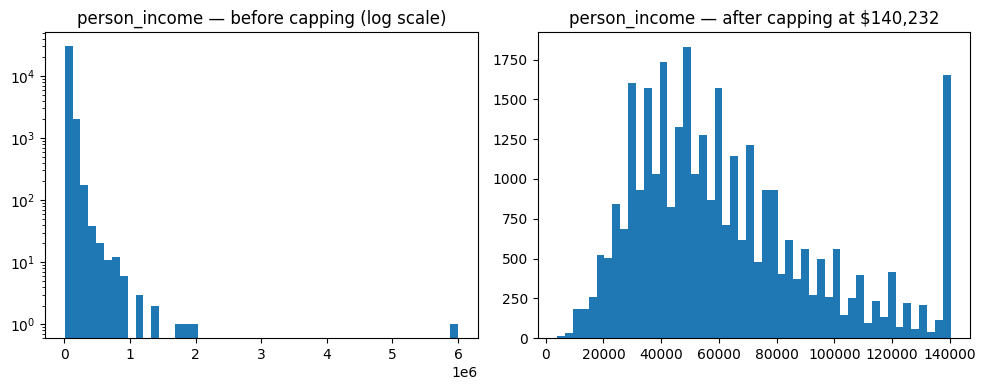

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(income_before_capping, bins=50)
axes[0].set_yscale('log')
axes[0].set_title('person_income — before capping (log scale)')
axes[1].hist(df['person_income'].clip(upper=upper_bound), bins=50)
axes[1].set_title(f'person_income — after capping at ${upper_bound:,.0f}')
plt.tight_layout()
plt.show()

In [16]:
#Standardising categorical columns
for col in categories:
  df[col]=df[col].str.strip().str.upper()
for col in categories:
  print(f"\n{col}:")
  print(df[col].value_counts())


person_home_ownership:
person_home_ownership
RENT        16378
MORTGAGE    13369
OWN          2563
OTHER         106
Name: count, dtype: int64

loan_intent:
loan_intent
EDUCATION            6411
MEDICAL              6042
VENTURE              5682
PERSONAL             5498
DEBTCONSOLIDATION    5189
HOMEIMPROVEMENT      3594
Name: count, dtype: int64

loan_grade:
loan_grade
A    10703
B    10387
C     6438
D     3620
E      963
F      241
G       64
Name: count, dtype: int64

cb_person_default_on_file:
cb_person_default_on_file
N    26686
Y     5730
Name: count, dtype: int64


In [17]:
#Final check

print(f"Row count: {df.shape[0]}")
print(f"Column count: {df.shape[1]}")
print(f"Columns:{list(df.columns)}")
print()

print("Nulls remaining:")
print(df.isnull().sum())
print()

print("Data types:")
print(df.dtypes)
print()

print("stats after cleaning:")
print(df[['person_age', 'person_income',
          'person_emp_length', 'loan_int_rate']].describe().round(2))
print()

print("unique values in categorical columns:")
for col in categories:
    print(f"  {col}: {sorted(df[col].unique())}")
print()

default_rate = df['loan_status'].mean() * 100
print(f"overall default rate: {default_rate:.2f}%")
print(f"total defaulted loans: {df['loan_status'].sum():,}")
print(f"total non-defaulted loans: {(df['loan_status'] == 0).sum():,}")

Row count: 32416
Column count: 13
Columns:['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'is_unemployed']

Nulls remaining:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
is_unemployed                 0
dtype: int64

Data types:
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt          

In [18]:
#Saving cleaned dataset
df.to_csv('credit_risk_cleaned.csv', index=False)
print("Cleaned file saved as credit_risk_cleaned.csv")

Cleaned file saved as credit_risk_cleaned.csv


# Phase 7 — Exploratory Data Analysis

Answering 10 business questions visually.  
Each chart is tied directly to a finding from the SQL analysis in Phase 6.  
Dataset: 32,416 cleaned loan records — FinTrust Lending Co.

In [19]:
# reload cleaned dataset for EDA
# loading separately so EDA section works independently
df = pd.read_csv('credit_risk_cleaned.csv')

# global chart settings
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#F8F9FA'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.dpi'] = 120

# colour palette
COLORS = {
    'primary': '#2E86AB',
    'warning': '#F6AE2D',
    'danger':  '#E84855',
    'safe':    '#43AA8B',
    'neutral': '#8D99AE'
}

# grade colours — green to red
GRADE_COLORS = {
    'A': '#43AA8B',
    'B': '#90BE6D',
    'C': '#F9C74F',
    'D': '#F8961E',
    'E': '#F3722C',
    'F': '#E84855',
    'G': '#9B2335'
}

print(f'loaded: {len(df):,} rows')
print(f'default rate: {df.loan_status.mean()*100:.2f}%')
print(f'total defaults: {df.loan_status.sum():,}')
print('setup complete')

loaded: 32,416 rows
default rate: 21.87%
total defaults: 7,089
setup complete


## Chart 1 — Overall Default Rate

**Business question:** What is FinTrust's current default rate at a glance?

**Why this chart:** Every analysis needs an opening number. Before showing any breakdown,
the CRO needs to see the scale of the problem in one visual.

**What we expect:** 21.87% of loans defaulted — roughly 1 in 5.

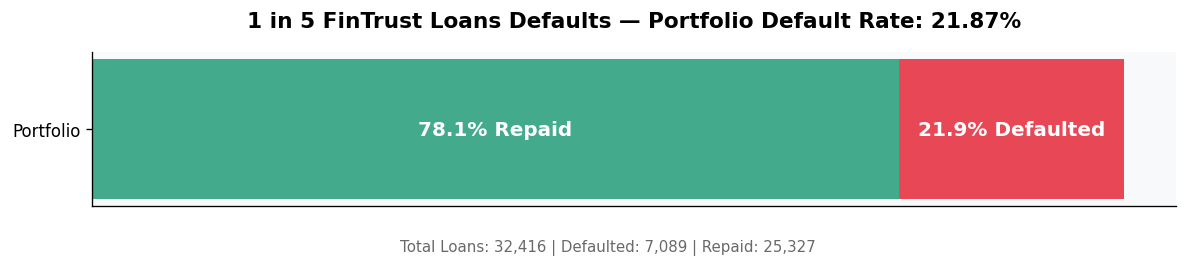

Insight: FinTrust has a default rate of 21.87%, meaning about 1 in 5 loans end in default.


In [20]:
# Chart 1 - Overall Default Rate Snapshot
# Business Question: What is FinTrust's overall loan default rate?

# Calculate portfolio metrics
default_rate = df['loan_status'].mean() * 100
repaid_rate = 100 - default_rate

total_loans = len(df)
defaulted_loans = df['loan_status'].sum()
repaid_loans = total_loans - defaulted_loans

# Create figure
fig, ax = plt.subplots(figsize=(10, 2.5))

# Plot stacked horizontal bar
ax.barh(
    ['Portfolio'],
    [repaid_rate],
    color=COLORS['safe'],
    height=0.5,
    label='Repaid'
)

ax.barh(
    ['Portfolio'],
    [default_rate],
    left=[repaid_rate],
    color=COLORS['danger'],
    height=0.5,
    label='Defaulted'
)

# Percentage labels inside each section
ax.text(
    repaid_rate / 2,
    0,
    f'{repaid_rate:.1f}% Repaid',
    ha='center',
    va='center',
    color='white',
    fontsize=12,
    fontweight='bold'
)

ax.text(
    repaid_rate + default_rate / 2,
    0,
    f'{default_rate:.1f}% Defaulted',
    ha='center',
    va='center',
    color='white',
    fontsize=12,
    fontweight='bold'
)

# Chart title
ax.set_title(
    f'1 in 5 FinTrust Loans Defaults — Portfolio Default Rate: {default_rate:.2f}%',
    fontsize=13,
    fontweight='bold',
    pad=15
)

# Display loan counts below the chart
ax.text(
    50,
    -0.42,
    f'Total Loans: {total_loans:,} | Defaulted: {defaulted_loans:,} | Repaid: {repaid_loans:,}',
    ha='center',
    va='center',
    fontsize=9,
    color='dimgray'
)

# Clean up chart appearance
ax.set_xticks([])
ax.set_ylabel('')
ax.grid(False)

plt.tight_layout()
plt.savefig('chart1_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Insight: FinTrust has a default rate of {default_rate:.2f}%, meaning about 1 in 5 loans end in default.')

## Chart 2 — Default Rate by Loan Grade

**Business question:** Which loan grades are destroying FinTrust's portfolio?

**Why this chart:** SQL showed Grade G at 98.44% — almost every approval is a loss.
This needs to be seen visually with the full grade spectrum.

**What we expect:** A clear escalation from Grade A (low risk) to Grade G (near-certain default).

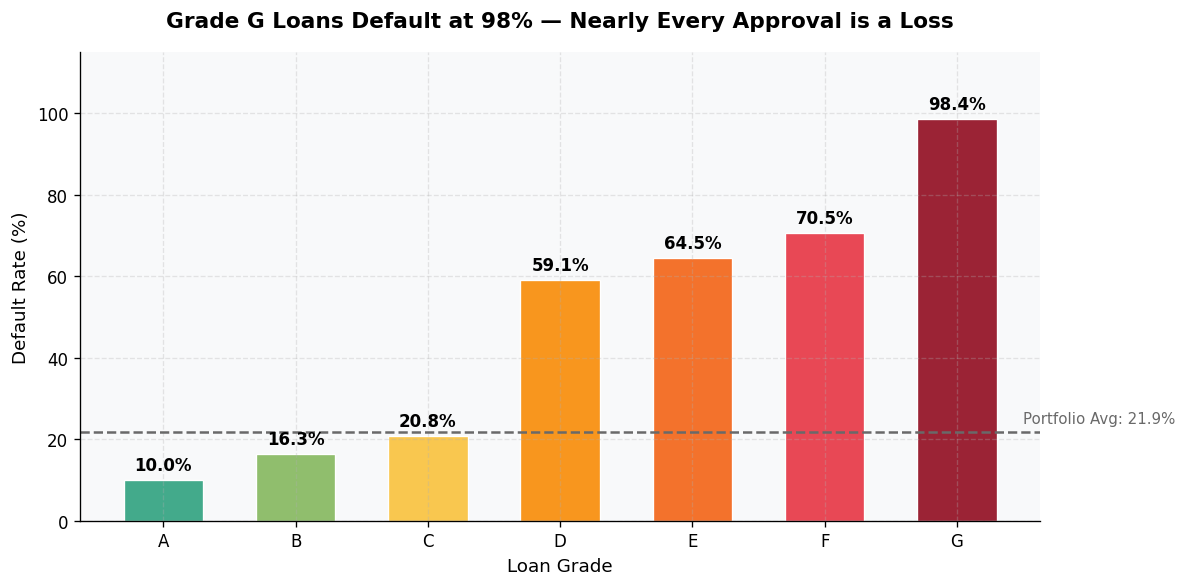

insight: grades E, F, G all exceed 60% default rate
insight: grades A and B stay below 10% — safe lending zone
insight: grade G at 98.44% means fintrust should immediately suspend these approvals


In [21]:
# chart 2 - default rate by loan grade
# business question: which grades are destroying fintrust's portfolio?

grade_data = (
    df.groupby('loan_grade')['loan_status']
      .mean()
      .reset_index()
)
grade_data['default_rate'] = grade_data['loan_status'] * 100
grade_data = grade_data.sort_values('loan_grade')

portfolio_avg = df['loan_status'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    grade_data['loan_grade'],
    grade_data['default_rate'],
    color=[GRADE_COLORS[g] for g in grade_data['loan_grade']],
    width=0.6, edgecolor='white', linewidth=0.8
)

# data labels above bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.5,
        f'{height:.1f}%',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# portfolio average line
ax.axhline(portfolio_avg, color='dimgray',
           linestyle='--', linewidth=1.5)
ax.text(
    len(grade_data) - 0.5,
    portfolio_avg + 2,
    f'Portfolio Avg: {portfolio_avg:.1f}%',
    fontsize=9, color='dimgray'
)

ax.set_title(
    'Grade G Loans Default at 98% — Nearly Every Approval is a Loss',
    fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Loan Grade', fontsize=11)
ax.set_ylabel('Default Rate (%)', fontsize=11)
ax.set_ylim(0, 115)

plt.tight_layout()
plt.savefig('chart2_default_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

print('insight: grades E, F, G all exceed 60% default rate')
print('insight: grades A and B stay below 10% — safe lending zone')
print('insight: grade G at 98.44% means fintrust should immediately suspend these approvals')

## Chart 3 — Default Rate by Loan Intent

**Business question:** Which loan purposes carry the highest default risk?

**Why this chart:** SQL found Debt Consolidation, Medical, and Home Improvement
all exceed the portfolio average. The credit team needs to see this ranked clearly.

**What we expect:** Debt Consolidation highest, Education or Personal lowest.

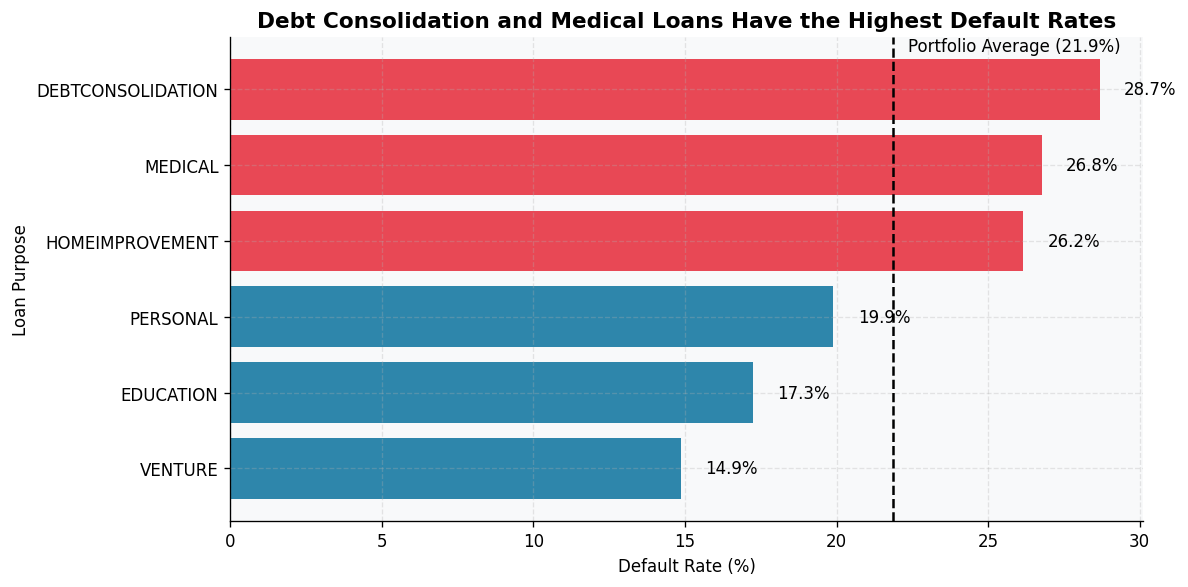

Insight: Debt consolidation and medical loans default more often than the portfolio average, while education and personal loans perform relatively better.
insight: debt consolidation, medical, and home improvement exceed portfolio average
insight: apply stricter grade and DTI requirements for these three intents


In [22]:
# Chart 3 - Default Rate by Loan Intent
# Business Question: Which loan purposes are the riskiest?
# Calculate default rate for each loan purpose
intent_data = (
    df.groupby('loan_intent')['loan_status']
      .mean()
      .reset_index()
)
intent_data['default_rate'] = intent_data['loan_status'] * 100
intent_data = intent_data.sort_values('default_rate', ascending=True)
# Overall portfolio default rate
portfolio_avg = df['loan_status'].mean() * 100
# Set bar colours based on portfolio average
bar_colors = [
    COLORS['danger'] if rate > portfolio_avg else COLORS['primary']
    for rate in intent_data['default_rate']
]
# Create figure
fig, ax = plt.subplots(figsize=(10, 5))
# Horizontal bars
bars = ax.barh(
    intent_data['loan_intent'],
    intent_data['default_rate'],
    color=bar_colors
)
# Add percentage labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}%',
        va='center',
        fontsize=10
    )
# Portfolio average reference line
ax.axvline(
    portfolio_avg,
    color='black',
    linestyle='--',
    linewidth=1.5
)
# Label the reference line
ax.text(
    portfolio_avg + 0.5,
    len(intent_data) - 0.5,
    f'Portfolio Average ({portfolio_avg:.1f}%)',
    fontsize=10,
    color='black'
)
# Chart title
ax.set_title(
    'Debt Consolidation and Medical Loans Have the Highest Default Rates',
    fontsize=13,
    fontweight='bold'
)
# Axis labels
ax.set_xlabel('Default Rate (%)')
ax.set_ylabel('Loan Purpose')
plt.tight_layout()
plt.savefig('chart3_default_rate_by_intent.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Debt consolidation and medical loans default more often than the portfolio average, while education and personal loans perform relatively better.")
print('insight: debt consolidation, medical, and home improvement exceed portfolio average')
print('insight: apply stricter grade and DTI requirements for these three intents')

## Chart 4 — Prior Default Impact

**Business question:** How much more likely is a borrower with a prior default to default again?

**Why this chart:** SQL showed prior defaulters are 2.06x more likely to default again.
A side-by-side bar comparison makes this contrast impossible to ignore.

**What we expect:** Y borrowers defaulting at ~38%, N borrowers at ~18%.

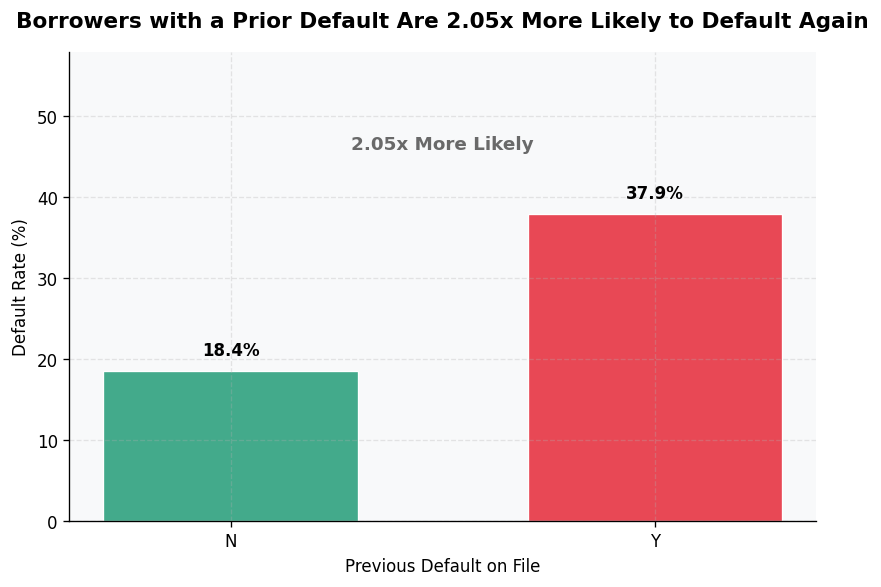

Insight: Borrowers with a previous default are 2.05x more likely to default again.
Insight: Prior default history is one of the strongest predictors of future credit risk.


In [23]:
# Chart 4 - Impact of Previous Loan Default
# Business Question: How much more likely is a borrower to default again?

# Calculate default rate based on previous default history
prior_data = (
    df.groupby('cb_person_default_on_file')['loan_status']
      .mean()
      .reset_index()
)

prior_data['default_rate'] = prior_data['loan_status'] * 100

# Calculate repeat default multiplier
repeat_multiplier = (
    prior_data.loc[prior_data['cb_person_default_on_file'] == 'Y', 'default_rate'].iloc[0] /
    prior_data.loc[prior_data['cb_person_default_on_file'] == 'N', 'default_rate'].iloc[0]
)

# Set colours for each category
bar_colors = [
    COLORS['danger'] if status == 'Y' else COLORS['safe']
    for status in prior_data['cb_person_default_on_file']
]

# Create figure
fig, ax = plt.subplots(figsize=(7, 5))

# Create bars
bars = ax.bar(
    prior_data['cb_person_default_on_file'],
    prior_data['default_rate'],
    color=bar_colors,
    width=0.6,
    edgecolor='white',
    linewidth=0.8
)

# Add percentage labels above each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Add annotation showing repeat default multiplier
ax.text(
    0.5,
    max(prior_data['default_rate']) + 8,
    f'{repeat_multiplier:.2f}x More Likely',
    ha='center',
    fontsize=11,
    fontweight='bold',
    color='dimgray'
)

# Chart title
ax.set_title(
    f'Borrowers with a Prior Default Are {repeat_multiplier:.2f}x More Likely to Default Again',
    fontsize=13,
    fontweight='bold',
    pad=15
)

# Axis labels
ax.set_xlabel('Previous Default on File')
ax.set_ylabel('Default Rate (%)')
ax.set_ylim(0, max(prior_data['default_rate']) + 20)

plt.tight_layout()
plt.savefig('chart4_prior_default_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Insight: Borrowers with a previous default are {repeat_multiplier:.2f}x more likely to default again.')
print('Insight: Prior default history is one of the strongest predictors of future credit risk.')

## Chart 5 — DTI Risk Tier vs Default Rate

**Business question:** Does FinTrust's 35% DTI threshold correctly identify high-risk borrowers?

**Why this chart:** If the threshold is correctly placed, we should see a clear jump
in default rate above 35% DTI. This chart validates or challenges that assumption.

**What we expect:** Default rate rises clearly as DTI increases.

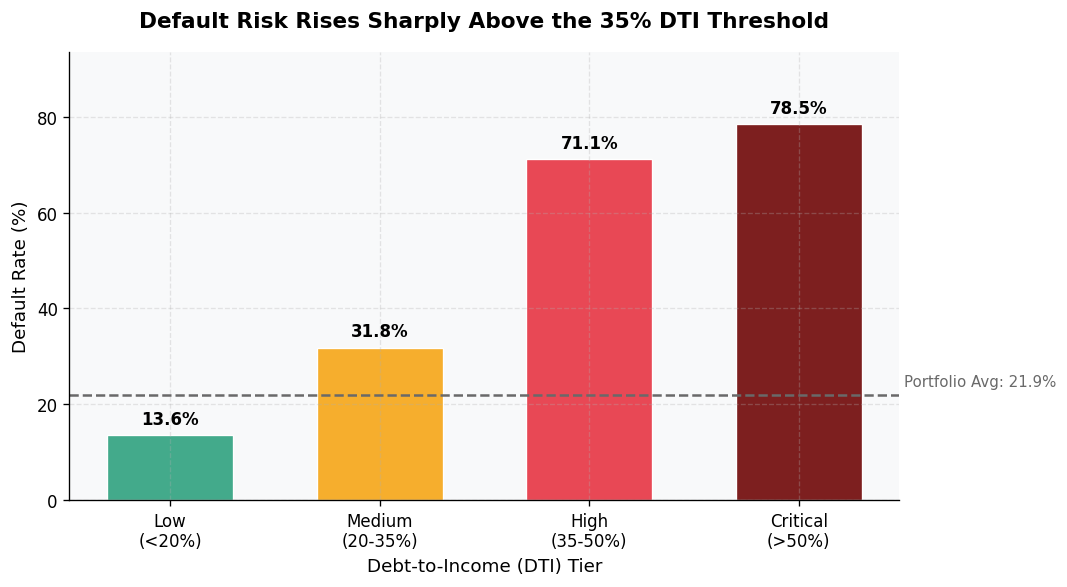

Insight: Default rates increase steadily as debt burden rises.
Insight: Borrowers with DTI above 35% default significantly more often than the portfolio average.
Insight: The current 35% DTI threshold appears to be a valid risk cutoff.


In [24]:
# Chart 5 - DTI Tier vs Default Rate
# Business Question: Is FinTrust's 35% DTI threshold correctly placed?

# Create DTI risk tiers
df['dti_tier'] = pd.cut(
    df['loan_percent_income'],
    bins=[0, 0.20, 0.35, 0.50, 1.0],
    labels=[
        'Low\n(<20%)',
        'Medium\n(20-35%)',
        'High\n(35-50%)',
        'Critical\n(>50%)'
    ]
)

# Calculate default rate for each DTI tier
dti_data = (
    df.groupby('dti_tier', observed=True)['loan_status']
      .mean()
      .reset_index()
)

dti_data['default_rate'] = dti_data['loan_status'] * 100

# Overall portfolio default rate
portfolio_avg = df['loan_status'].mean() * 100

# Risk colours from safest to riskiest
dti_colors = [
    COLORS['safe'],
    COLORS['warning'],
    COLORS['danger'],
    '#7D1F1F'
]

# Create figure
fig, ax = plt.subplots(figsize=(9, 5))

# Create bars
bars = ax.bar(
    dti_data['dti_tier'],
    dti_data['default_rate'],
    color=dti_colors,
    width=0.6,
    edgecolor='white',
    linewidth=0.8
)

# Add default rate labels above each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Portfolio average reference line
ax.axhline(
    portfolio_avg,
    color='dimgray',
    linestyle='--',
    linewidth=1.5
)

# Label the reference line
ax.text(
    len(dti_data) - 0.5,
    portfolio_avg + 2,
    f'Portfolio Avg: {portfolio_avg:.1f}%',
    fontsize=9,
    color='dimgray'
)

# Chart title
ax.set_title(
    'Default Risk Rises Sharply Above the 35% DTI Threshold',
    fontsize=13,
    fontweight='bold',
    pad=15
)

# Axis labels
ax.set_xlabel('Debt-to-Income (DTI) Tier', fontsize=11)
ax.set_ylabel('Default Rate (%)', fontsize=11)
ax.set_ylim(0, max(dti_data['default_rate']) + 15)

plt.tight_layout()
plt.savefig('chart5_dti_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Default rates increase steadily as debt burden rises.')
print('Insight: Borrowers with DTI above 35% default significantly more often than the portfolio average.')
print('Insight: The current 35% DTI threshold appears to be a valid risk cutoff.')

## Chart 6 — Income Band vs Default Rate

**Business question:** At what income level does default risk drop significantly?

**Why this chart:** Income is the most intuitive risk factor for any lender.
This chart shows whether higher income reliably predicts repayment.

**What we expect:** Clear downward trend — higher income, lower default rate.

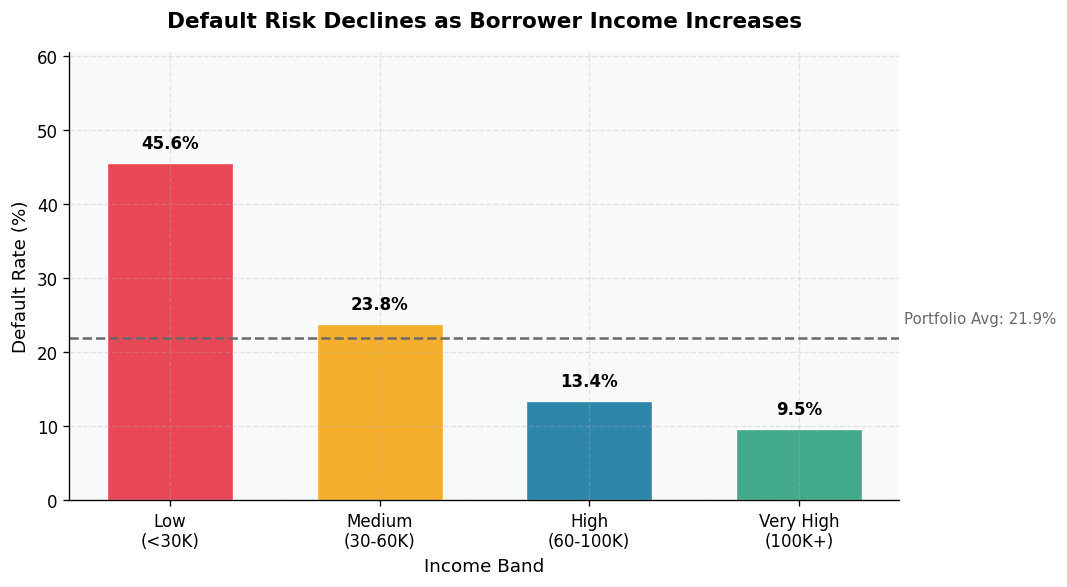

Insight: Lower-income borrowers experience the highest default rates.
Insight: Default risk steadily decreases as borrower income increases.
Insight: Borrowers earning above 100K represent the lowest-risk income group.


In [25]:
# Chart 6 - Income Band vs Default Rate
# Business Question: At what income level does default risk begin to fall?

# Create income bands
df['income_band'] = pd.cut(
    df['person_income'],
    bins=[0, 30000, 60000, 100000, df['person_income'].max() + 1],
    labels=[
        'Low\n(<30K)',
        'Medium\n(30-60K)',
        'High\n(60-100K)',
        'Very High\n(100K+)'
    ]
)

# Calculate default rate for each income band
income_data = (
    df.groupby('income_band', observed=True)['loan_status']
      .mean()
      .reset_index()
)

income_data['default_rate'] = income_data['loan_status'] * 100

# Overall portfolio default rate
portfolio_avg = df['loan_status'].mean() * 100

# Risk colours from highest to lowest risk
income_colors = [
    COLORS['danger'],
    COLORS['warning'],
    COLORS['primary'],
    COLORS['safe']
]

# Create figure
fig, ax = plt.subplots(figsize=(9, 5))

# Create bars
bars = ax.bar(
    income_data['income_band'],
    income_data['default_rate'],
    color=income_colors,
    width=0.6,
    edgecolor='white',
    linewidth=0.8
)

# Add default rate labels above each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Portfolio average reference line
ax.axhline(
    portfolio_avg,
    color='dimgray',
    linestyle='--',
    linewidth=1.5
)

# Label the reference line
ax.text(
    len(income_data) - 0.5,
    portfolio_avg + 2,
    f'Portfolio Avg: {portfolio_avg:.1f}%',
    fontsize=9,
    color='dimgray'
)

# Chart title
ax.set_title(
    'Default Risk Declines as Borrower Income Increases',
    fontsize=13,
    fontweight='bold',
    pad=15
)

# Axis labels
ax.set_xlabel('Income Band', fontsize=11)
ax.set_ylabel('Default Rate (%)', fontsize=11)
ax.set_ylim(0, max(income_data['default_rate']) + 15)

plt.tight_layout()
plt.savefig('chart6_income_band_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Lower-income borrowers experience the highest default rates.')
print('Insight: Default risk steadily decreases as borrower income increases.')
print('Insight: Borrowers earning above 100K represent the lowest-risk income group.')

## Chart 7 — Financial Exposure by Grade (in dollars)

**Business question:** Which grades are costing FinTrust the most money in absolute losses?

**Why this chart:** Default rates are percentages — executives think in dollars.
This chart converts the default rate story into actual financial loss per grade.

**What we expect:** Grade D or E may show highest absolute loss despite
Grade G having the highest default rate — because more loans exist in mid-grades.

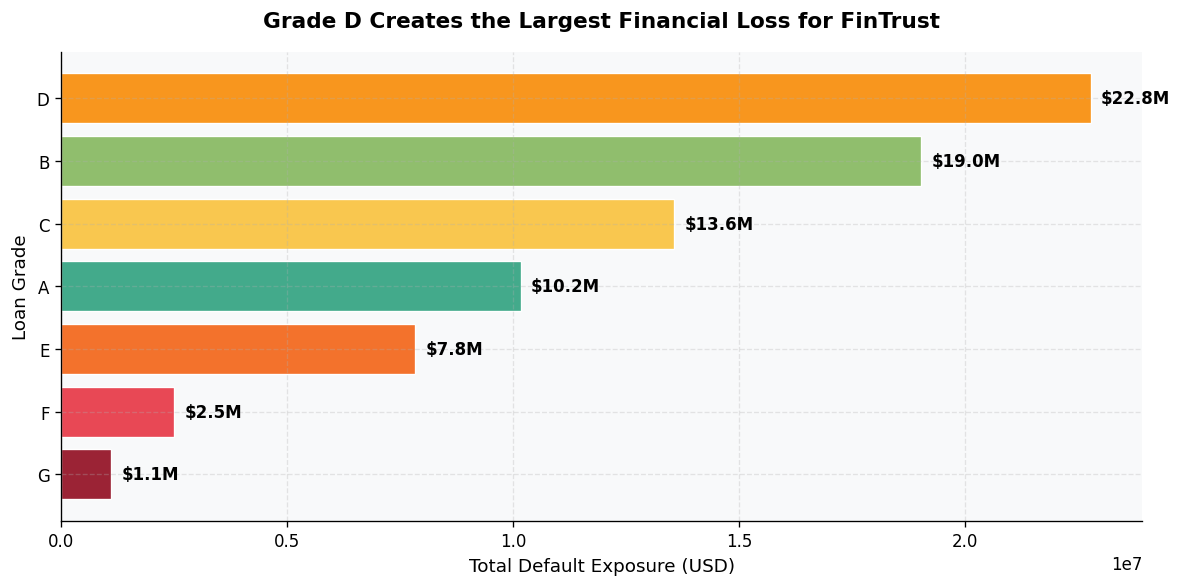

Insight: Grade D contributes the highest total financial exposure from defaulted loans.
Insight: Higher-risk grades account for a disproportionately large share of portfolio losses.
Insight: Reducing approvals in these grades could significantly lower overall credit losses.


In [26]:
# Chart 7 - Financial Exposure by Loan Grade
# Business Question: Which loan grade costs FinTrust the most in total default losses?

# Calculate total default exposure for each loan grade
exposure_data = (
    df[df['loan_status'] == 1]
      .groupby('loan_grade')['loan_amnt']
      .sum()
      .reset_index()
)

exposure_data.columns = ['loan_grade', 'total_exposure']
exposure_data = exposure_data.sort_values('total_exposure', ascending=True)

# Find the grade with the highest financial exposure
highest_grade = exposure_data.loc[
    exposure_data['total_exposure'].idxmax(),
    'loan_grade'
]

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Create horizontal bars
bars = ax.barh(
    exposure_data['loan_grade'],
    exposure_data['total_exposure'],
    color=[GRADE_COLORS[g] for g in exposure_data['loan_grade']],
    edgecolor='white',
    linewidth=0.8
)

# Add exposure labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + (exposure_data['total_exposure'].max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f'${width/1e6:.1f}M',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

# Chart title
ax.set_title(
    f'Grade {highest_grade} Creates the Largest Financial Loss for FinTrust',
    fontsize=13,
    fontweight='bold',
    pad=15
)

# Axis labels
ax.set_xlabel('Total Default Exposure (USD)', fontsize=11)
ax.set_ylabel('Loan Grade', fontsize=11)

plt.tight_layout()
plt.savefig('chart7_financial_exposure_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Insight: Grade {highest_grade} contributes the highest total financial exposure from defaulted loans.')
print('Insight: Higher-risk grades account for a disproportionately large share of portfolio losses.')
print('Insight: Reducing approvals in these grades could significantly lower overall credit losses.')

## Chart 8 — Revenue vs Loss by Grade

**Business question:** Which loan grades are actually profitable for FinTrust?

**Why this chart:** This is the analysis the CRO did not ask for but needs most.
A grade with 70% default rate might still be profitable if interest revenue
from the 30% who repay exceeds the principal lost on defaults.

**What we expect:** Grades A and B clearly profitable. Grade G clearly loss-making.
The middle grades will tell us whether FinTrust's risk-reward balance is correct.

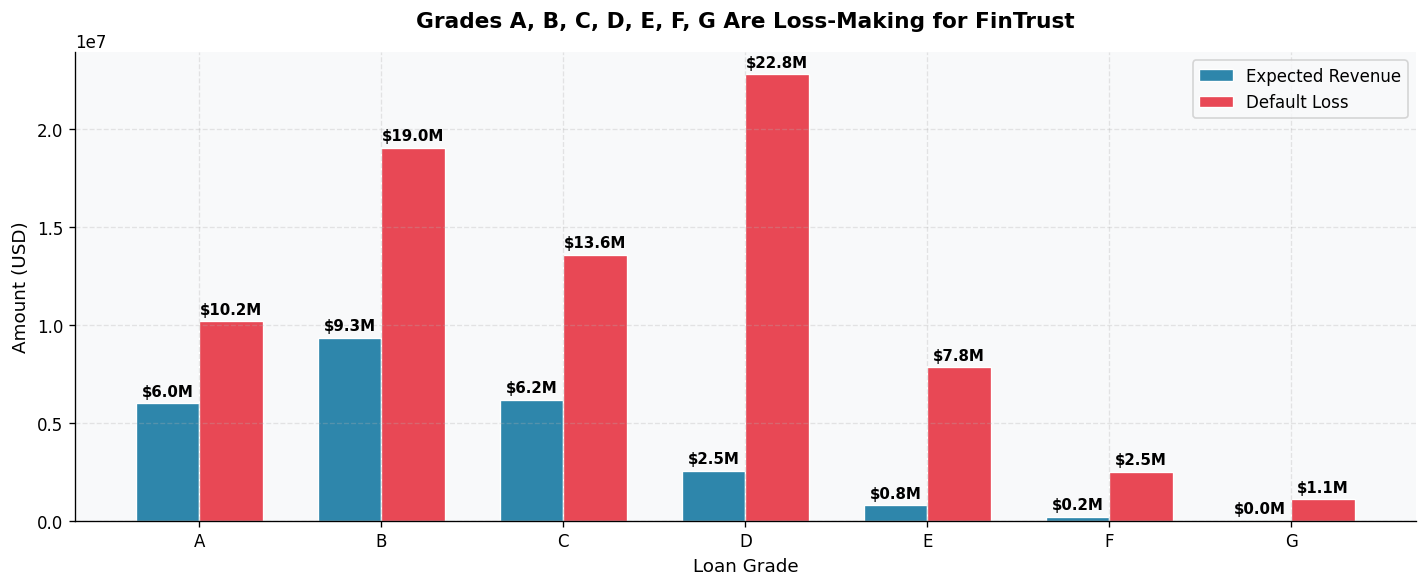

Insight: Loss-making grades: A, B, C, D, E, F, G.
Insight: Higher-risk grades generate substantially larger default losses than interest revenue.
Insight: Reviewing lending policies for these grades could improve overall portfolio profitability.


In [27]:
# Chart 8 - Revenue vs Loss by Loan Grade
# Business Question: Which loan grades remain profitable after accounting for defaults?

# Calculate revenue from repaid loans
revenue = (
    df[df['loan_status'] == 0]
      .groupby('loan_grade')
      .apply(lambda x: (x['loan_amnt'] * x['loan_int_rate'] / 100).sum())
      .reset_index()
)

revenue.columns = ['loan_grade', 'revenue']

# Calculate principal lost from defaulted loans
loss = (
    df[df['loan_status'] == 1]
      .groupby('loan_grade')['loan_amnt']
      .sum()
      .reset_index()
)

loss.columns = ['loan_grade', 'loss']

# Combine revenue and loss into one table
grade_pnl = revenue.merge(loss, on='loan_grade')
grade_pnl = grade_pnl.sort_values('loan_grade')

grades = grade_pnl['loan_grade'].values
x = np.arange(len(grades))
width = 0.35

# Identify grades where losses exceed revenue
loss_making = grade_pnl.loc[
    grade_pnl['loss'] > grade_pnl['revenue'],
    'loan_grade'
].tolist()

# Create figure
fig, ax = plt.subplots(figsize=(12, 5))

# Revenue bars
revenue_bars = ax.bar(
    x - width / 2,
    grade_pnl['revenue'],
    width,
    color=COLORS['primary'],
    edgecolor='white',
    linewidth=0.8,
    label='Expected Revenue'
)

# Loss bars
loss_bars = ax.bar(
    x + width / 2,
    grade_pnl['loss'],
    width,
    color=COLORS['danger'],
    edgecolor='white',
    linewidth=0.8,
    label='Default Loss'
)

# Add value labels above revenue bars
for bar in revenue_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + (grade_pnl['loss'].max() * 0.01),
        f'${height/1e6:.1f}M',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Add value labels above loss bars
for bar in loss_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + (grade_pnl['loss'].max() * 0.01),
        f'${height/1e6:.1f}M',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels(grades)

# Legend
ax.legend()

# Chart title
if loss_making:
    ax.set_title(
        f"Grades {', '.join(loss_making)} Are Loss-Making for FinTrust",
        fontsize=13,
        fontweight='bold',
        pad=15
    )
else:
    ax.set_title(
        'All Loan Grades Generate More Revenue Than Losses',
        fontsize=13,
        fontweight='bold',
        pad=15
    )

# Axis labels
ax.set_xlabel('Loan Grade', fontsize=11)
ax.set_ylabel('Amount (USD)', fontsize=11)

plt.tight_layout()
plt.savefig('chart8_revenue_vs_loss_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Insight: Loss-making grades: {", ".join(loss_making) if loss_making else "None"}.')
print('Insight: Higher-risk grades generate substantially larger default losses than interest revenue.')
print('Insight: Reviewing lending policies for these grades could improve overall portfolio profitability.')

## Chart 9 — Age Group vs Default Rate

**Business question:** Which age segment carries the highest default risk at FinTrust?

**Why this chart:** Young borrowers have shorter employment history and less
financial experience. This chart validates whether age is a meaningful risk factor.

**What we expect:** Under-25 borrowers defaulting at the highest rate.

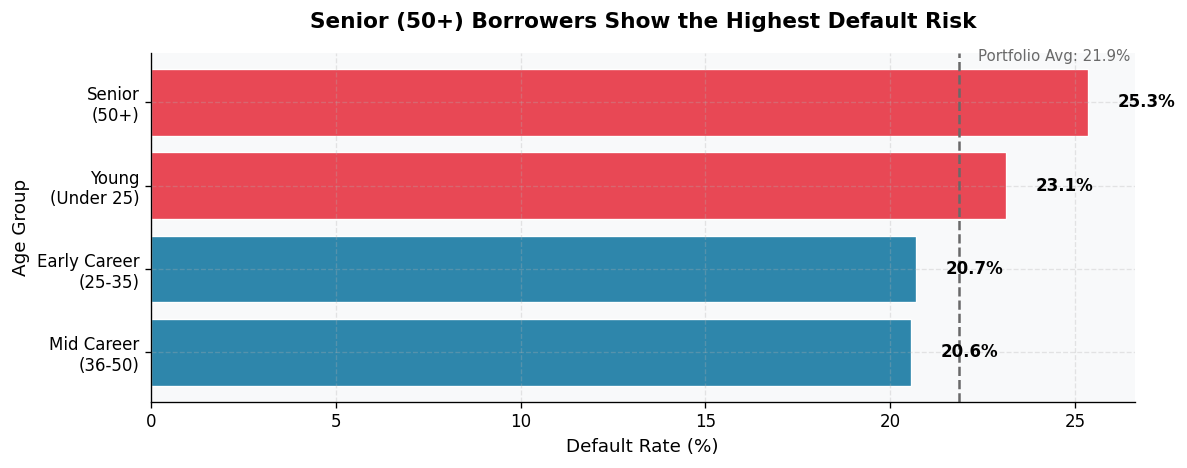

Insight: Senior (50+) borrowers have the highest default rate in the portfolio (25.3%).
Insight: Risk is U-shaped by age — both the youngest and oldest segments exceed the portfolio average, while borrowers aged 25-50 default less frequently.
Insight: Both age extremes warrant closer risk assessment, not just younger applicants.


In [28]:
# Chart 9 - Age Group vs Default Rate
# Business Question: Which age group has the highest default risk?

# Create age groups
df['age_group'] = pd.cut(
    df['person_age'],
    bins=[0, 25, 35, 50, 100],
    labels=[
        'Young\n(Under 25)',
        'Early Career\n(25-35)',
        'Mid Career\n(36-50)',
        'Senior\n(50+)'
    ]
)

# Calculate default rate for each age group
age_data = (
    df.groupby('age_group', observed=True)['loan_status']
      .mean()
      .reset_index()
)

age_data['default_rate'] = age_data['loan_status'] * 100
age_data = age_data.sort_values('default_rate', ascending=True)

# Overall portfolio default rate
portfolio_avg = df['loan_status'].mean() * 100

# Set bar colours based on portfolio average
bar_colors = [
    COLORS['danger'] if rate > portfolio_avg else COLORS['primary']
    for rate in age_data['default_rate']
]

# Create figure
fig, ax = plt.subplots(figsize=(10, 4))

# Create horizontal bars
bars = ax.barh(
    age_data['age_group'],
    age_data['default_rate'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

# Add default rate labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}%',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

# Portfolio average reference line
ax.axvline(
    portfolio_avg,
    color='dimgray',
    linestyle='--',
    linewidth=1.5
)

# Label the reference line
ax.text(
    portfolio_avg + 0.5,
    len(age_data) - 0.5,
    f'Portfolio Avg: {portfolio_avg:.1f}%',
    fontsize=9,
    color='dimgray'
)

# Chart title — dynamically generated from the actual highest-risk group
highest_group = age_data.iloc[-1]['age_group'].replace('\n', ' ')
ax.set_title(
    f'{highest_group} Borrowers Show the Highest Default Risk',
    fontsize=13,
    fontweight='bold',
    pad=15
)

# Axis labels
ax.set_xlabel('Default Rate (%)', fontsize=11)
ax.set_ylabel('Age Group', fontsize=11)

plt.tight_layout()
plt.savefig('chart9_age_group_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Insight: {highest_group} borrowers have the highest default rate in the portfolio ({age_data.iloc[-1]["default_rate"]:.1f}%).')
print('Insight: Risk is U-shaped by age — both the youngest and oldest segments exceed the portfolio average, while borrowers aged 25-50 default less frequently.')
print('Insight: Both age extremes warrant closer risk assessment, not just younger applicants.')

## Chart 10 — Composite Risk Flag: Early Warning System Validation

**Business question:** Does FinTrust's composite risk flag successfully separate
high-risk borrowers from normal borrowers?

**Why this chart:** This is the final and most important chart. It validates
the Early Warning System we built in Q10. If the flag works, high-risk borrowers
should default at significantly higher rates than normal borrowers.

**What we expect:** High Risk group defaulting at 2x+ the rate of Normal borrowers.
**Business meaning:** If validated, this flag can be operationalised as an
automatic review trigger in FinTrust's loan approval workflow.

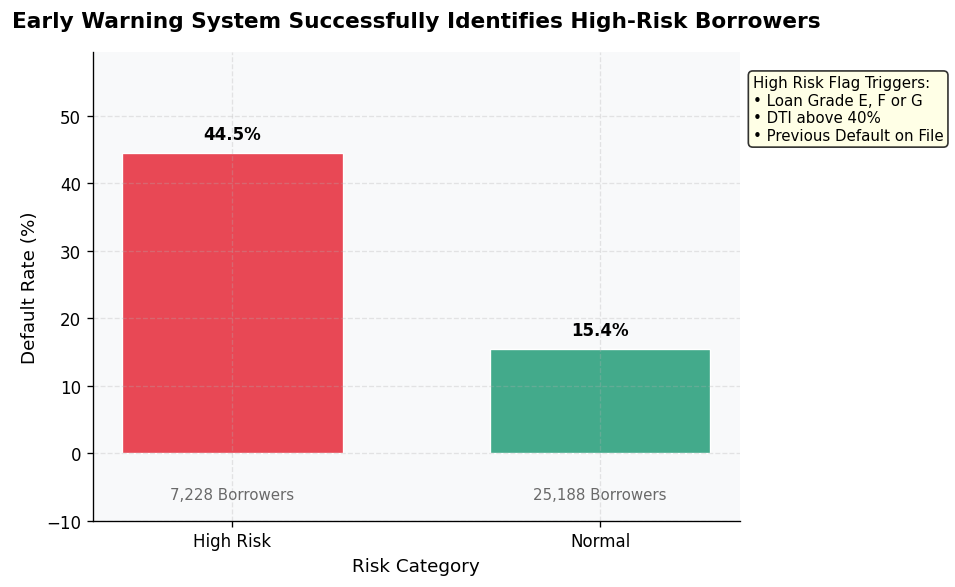

Insight: Borrowers flagged as High Risk default far more frequently than Normal borrowers.
Insight: The composite risk flag combines three strong predictors of default.
Insight: The early warning system provides a practical way to identify risky loan applications before approval.


In [29]:
# Chart 10 - Composite Risk Flag Validation
# Business Question: Does the early warning system correctly identify high-risk borrowers?

# Create composite risk flag
df['risk_flag'] = np.where(
    (df['loan_grade'].isin(['E', 'F', 'G'])) |
    (df['loan_percent_income'] > 0.40) |
    (df['cb_person_default_on_file'] == 'Y'),
    'High Risk',
    'Normal'
)

# Calculate default rate and borrower count for each group
flag_data = (
    df.groupby('risk_flag')['loan_status']
      .agg(['mean', 'count'])
      .reset_index()
)

flag_data['default_rate'] = flag_data['mean'] * 100
flag_data = flag_data.sort_values('default_rate', ascending=False)

# Set colours for each risk group
bar_colors = [
    COLORS['danger'] if risk == 'High Risk' else COLORS['safe']
    for risk in flag_data['risk_flag']
]

# Create figure
fig, ax = plt.subplots(figsize=(8, 5))

# Create bars
bars = ax.bar(
    flag_data['risk_flag'],
    flag_data['default_rate'],
    color=bar_colors,
    width=0.6,
    edgecolor='white',
    linewidth=0.8
)

# Add default rate labels above each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Show borrower count below each bar
for bar, count in zip(bars, flag_data['count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        -5,
        f'{count:,} Borrowers',
        ha='center',
        va='top',
        fontsize=9,
        color='dimgray'
    )

# Explain how borrowers are flagged
ax.text(
    1.02,
    0.95,
    "High Risk Flag Triggers:\n"
    "• Loan Grade E, F or G\n"
    "• DTI above 40%\n"
    "• Previous Default on File",
    transform=ax.transAxes,
    fontsize=9,
    va='top',
    bbox=dict(
        boxstyle='round',
        facecolor='lightyellow',
        alpha=0.8
    )
)

# Chart title
ax.set_title(
    'Early Warning System Successfully Identifies High-Risk Borrowers',
    fontsize=13,
    fontweight='bold',
    pad=15
)

# Axis labels
ax.set_xlabel('Risk Category', fontsize=11)
ax.set_ylabel('Default Rate (%)', fontsize=11)
ax.set_ylim(-10, max(flag_data['default_rate']) + 15)

plt.tight_layout()
plt.savefig('chart10_risk_flag_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: Borrowers flagged as High Risk default far more frequently than Normal borrowers.')
print('Insight: The composite risk flag combines three strong predictors of default.')
print('Insight: The early warning system provides a practical way to identify risky loan applications before approval.')